In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler
from skimage.metrics import structural_similarity as ssim
from math import log10
import json
import os
import time
import json
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim

import models
from processdata import TimeSeriesDataset

In [16]:
# # Define os caminhos de salvamento e carregamento
# # save_path = r"./results/csshred/testes"
# # load_path = r"./results/csshred/testes"
# save_path = r"/home/romulo/Documentos/lpips-env/home/romulo/Documentos/lpips-env/results/csshred/piv"
# load_path = r"/home/romulo/Documentos/lpips-env/home/romulo/Documentos/lpips-env/results/csshred/piv"

# # Carrega os arquivos necessários
# test_recons = np.load(load_path + r"/test_recons.npy")
# test_ground_truth = np.load(load_path + r"/test_ground_truth.npy")
# matrix = np.load(load_path + r"/matrix.npy")
# snapshot = np.load(load_path + r"/snapshot.npy")
# sensor_positions_x = np.load(load_path + r"/sensor_positions_x.npy")
# sensor_positions_y = np.load(load_path + r"/sensor_positions_y.npy")
# train_error = np.load(load_path + r"/train_error.npy")
# validation_errors = np.load(load_path + r"/validation_errors.npy")

In [17]:
# import json
# import os
# import numpy as np
# from math import log10
# import matplotlib.pyplot as plt
# from sklearn.metrics import mean_squared_error
# from skimage.metrics import structural_similarity as ssim

# def plot_results(
#     train_error, validation_errors, test_recons, test_ground_truth, matrix, subsampled,
#     save_path=r'./results/csshred/piv/'
# ):
#     # Certifique-se de que o diretório de salvamento existe
#     os.makedirs(save_path, exist_ok=True)
    
#     dim_x, dim_y, dim_t = subsampled.shape

#     # Reorganizar os dados mantendo a transposta para visualização
#     test_ground_truth = test_ground_truth.copy().reshape(-1, dim_x, dim_y)
#     test_ground_truth = np.transpose(test_ground_truth.copy(), (1, 2, 0))
#     test_recons = test_recons.reshape(-1, dim_x, dim_y)
#     subsampled = subsampled.reshape(dim_x, dim_y, -1)

#     print("test_recons shape:", test_recons.shape)
#     print("test_ground_truth shape:", test_ground_truth.shape)
#     print("subsampled shape:", subsampled.shape)

#     # Plot Training Error
#     plt.figure(figsize=(12, 6))
#     plt.plot(train_error, label="Training Error")
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss")
#     plt.title("Training Error Over Epochs")
#     plt.legend()
#     plt.savefig(os.path.join(save_path, "training_error.png"))
#     plt.show()

#     # Plot Validation Error
#     plt.figure(figsize=(12, 6))
#     plt.plot(validation_errors, label="Validation Error")
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss")
#     plt.title("Validation Error Over Epochs")
#     plt.legend()
#     plt.savefig(os.path.join(save_path, "validation_error.png"))
#     plt.show()

#     # Plot Last Snapshot - Reconstructed and Original
#     plt.figure(figsize=(14, 6))

#     ax1 = plt.subplot(1, 2, 1)
#     img1 = ax1.imshow(test_recons[-1], cmap='RdBu_r', interpolation='bilinear')
#     plt.colorbar(img1, ax=ax1)
#     ax1.set_title("Reconstructed - Last Snapshot")
#     ax1.set_xlabel("X")
#     ax1.set_ylabel("Y")
    
#     ax2 = plt.subplot(1, 2, 2)
#     img2 = ax2.imshow(test_ground_truth[:, :, -1], cmap='RdBu_r', interpolation='bilinear')
#     plt.colorbar(img2, ax=ax2)
#     ax2.set_title("Original - Last Snapshot")
#     ax2.set_xlabel("X")
#     ax2.set_ylabel("Y")
    
#     plt.tight_layout()
#     plt.savefig(os.path.join(save_path, "last_snapshot_comparison.png"))
#     plt.show()

#     # Plot Last Snapshot - Reconstructed and Subsampled
#     plt.figure(figsize=(14, 6))
    
#     ax3 = plt.subplot(1, 2, 1)
#     img3 = ax3.imshow(test_recons[-1], cmap='RdBu_r', interpolation='bilinear')
#     plt.colorbar(img3, ax=ax3)
#     ax3.set_title("Reconstructed - Last Snapshot")
#     ax3.set_xlabel("X")
#     ax3.set_ylabel("Y")
    
#     ax4 = plt.subplot(1, 2, 2)
#     img4 = ax4.imshow(subsampled[:, :, -1], cmap='RdBu_r', interpolation='bilinear')
#     plt.colorbar(img4, ax=ax4)
#     ax4.set_title("Subsampled - Last Snapshot")
#     ax4.set_xlabel("X")
#     ax4.set_ylabel("Y")
    
#     plt.tight_layout()
#     plt.savefig(os.path.join(save_path, "subsampled_snapshot_comparison.png"))
#     plt.show()
    
#     # Calculando métricas
#     ssim_value_last = ssim(
#         test_ground_truth[:, :, -1],
#         test_recons[-1],
#         data_range=test_ground_truth[:, :, -1].max() - test_ground_truth[:, :, -1].min(),
#     )
    
#     test_recons_mse = np.transpose(test_recons.copy(), (1,2,0))
#     mse_value_last = np.linalg.norm(test_recons_mse - test_ground_truth) / np.linalg.norm(test_ground_truth)
    
#     mse = mean_squared_error(test_ground_truth[:, :, -1], test_recons[-1])
#     max_pixel = np.max(test_ground_truth[:, :, -1])
#     psnr_value_last = 20 * log10(max_pixel / np.sqrt(mse))
    
#     print(f"SSIM for the last snapshot: {ssim_value_last}")
#     print(f"MSE for the last snapshot: {mse_value_last}")
#     print(f"PSNR for the last snapshot: {psnr_value_last} dB")
    
#     # Calculando médias para todos os snapshots
#     ssim_values = []
#     psnr_values = []
#     for i in range(test_recons.shape[0]):
#         ssim_value = ssim(
#             test_ground_truth[:, :, i],
#             test_recons[i],
#             data_range=test_ground_truth[:, :, i].max() - test_ground_truth[:, :, i].min(),
#         )
#         ssim_values.append(ssim_value)
        
#         mse = mean_squared_error(test_ground_truth[:, :, i], test_recons[i])
#         max_pixel = np.max(test_ground_truth[:, :, i])
#         psnr = 20 * log10(max_pixel / np.sqrt(mse))
#         psnr_values.append(psnr)
    
#     mean_ssim_value = np.mean(ssim_values)
#     mean_psnr_value = np.mean(psnr_values)
#     print(f"Mean SSIM for all snapshots: {mean_ssim_value}")
#     print(f"Mean PSNR for all snapshots: {mean_psnr_value} dB")

#     # Salvando resultados em JSON
#     results = {
#         "SSIM_last_snapshot": float(ssim_value_last),
#         "MSE_last_snapshot": float(mse_value_last),
#         "PSNR_last_snapshot": float(psnr_value_last),
#         "Mean_SSIM_all_snapshots": float(mean_ssim_value),
#         "Mean_PSNR_all_snapshots": float(mean_psnr_value),
#     }
    
#     json_file_path = os.path.join(save_path, "results.json")
#     with open(json_file_path, "w") as json_file:
#         json.dump(results, json_file, indent=4)
    
#     print(f"Results saved to {json_file_path}")
#     print(f"Plots saved to {save_path}")

In [18]:
# plot_results(train_error, validation_errors, test_recons, test_ground_truth, matrix, snapshot)

## CS-SHRED

In [43]:
# Define os caminhos de salvamento e carregamento
# save_path = r"./results/csshred/testes"
# load_path = r"./results/csshred/testes"
save_path = r"/home/romulo/Documentos/lpips-env/results/csshred/piv/result_paper"
load_path = r"/home/romulo/Documentos/lpips-env/results/csshred/piv/result_paper"

# Carrega os arquivos necessários
test_recons = np.load(load_path + r"/test_recons.npy")
test_ground_truth = np.load(load_path + r"/test_ground_truth.npy")
matrix = np.load(load_path + r"/matrix.npy")
snapshot = np.load(load_path + r"/snapshot.npy")
sensor_positions_x = np.load(load_path + r"/sensor_positions_x.npy")
sensor_positions_y = np.load(load_path + r"/sensor_positions_y.npy")
train_error = np.load(load_path + r"/train_error.npy")
validation_errors = np.load(load_path + r"/validation_errors.npy")

In [45]:
def plot_results(
    train_error, validation_errors, test_recons, test_ground_truth, matrix, subsampled,
    save_path=r'./results/csshred/piv/result_paper'
):
    # Certifique-se de que o diretório de salvamento existe
    os.makedirs(save_path, exist_ok=True)
    
    dim_x, dim_y, dim_t = subsampled.shape

    # Reorganizar os dados mantendo a transposta para visualização
    test_ground_truth = test_ground_truth.copy().reshape(-1, dim_x, dim_y)
    test_ground_truth = np.transpose(test_ground_truth.copy(), (1, 2, 0))
    test_recons = test_recons.reshape(-1, dim_x, dim_y)
    subsampled = subsampled.reshape(dim_x, dim_y, -1)

    print("test_recons shape:", test_recons.shape)
    print("test_ground_truth shape:", test_ground_truth.shape)
    print("subsampled shape:", subsampled.shape)

    # Plot Training Error
    plt.figure(figsize=(12, 6))
    plt.plot(train_error, label="Training Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Error Over Epochs")
    plt.legend()
    plt.savefig(os.path.join(save_path, "training_error.png"))
    plt.savefig(os.path.join(save_path, "training_error.pdf"))
    plt.show()

    # Plot Validation Error
    plt.figure(figsize=(12, 6))
    plt.plot(validation_errors, label="Validation Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Error Over Epochs")
    plt.legend()
    plt.savefig(os.path.join(save_path, "validation_error.png"))
    plt.savefig(os.path.join(save_path, "validation_error.pdf"))
    plt.show()

    # Plot Last Snapshot - Reconstructed and Original
    plt.figure(figsize=(14, 6))

    ax1 = plt.subplot(1, 2, 1)
    img1 = ax1.imshow(test_recons[-1], cmap='viridis', interpolation='bilinear', extent=[0, 1, 0, 1])
    plt.colorbar(img1, ax=ax1)
    ax1.set_title("Reconstructed - Last Snapshot")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    
    ax2 = plt.subplot(1, 2, 2)
    img2 = ax2.imshow(test_ground_truth[:, :, -1], cmap='viridis', interpolation='bilinear', extent=[0, 1, 0, 1])
    plt.colorbar(img2, ax=ax2)
    ax2.set_title("Original - Last Snapshot")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, "last_snapshot_comparison.png"))
    plt.savefig(os.path.join(save_path, "last_snapshot_comparison.pdf"))
    plt.show()

    # Plot Last Snapshot - Reconstructed and Subsampled
    plt.figure(figsize=(14, 6))
    
    ax3 = plt.subplot(1, 2, 1)
    img3 = ax3.imshow(test_recons[-1], cmap='viridis', interpolation='bilinear', extent=[0, 1, 0, 1])
    plt.colorbar(img3, ax=ax3)
    ax3.set_title("Reconstructed - Last Snapshot")
    ax3.set_xlabel("X")
    ax3.set_ylabel("Y")
    
    ax4 = plt.subplot(1, 2, 2)
    img4 = ax4.imshow(subsampled[:, :, -1], cmap='viridis', interpolation='bilinear', extent=[0, 1, 0, 1])
    plt.colorbar(img4, ax=ax4)
    ax4.set_title("Subsampled - Last Snapshot")
    ax4.set_xlabel("X")
    ax4.set_ylabel("Y")
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, "subsampled_snapshot_comparison.png"))
    plt.savefig(os.path.join(save_path, "subsampled_snapshot_comparison.pdf"))
    plt.show()
    
    # Calculando métricas
    ssim_value_last = ssim(
        test_ground_truth[:, :, -1],
        test_recons[-1],
        data_range=test_ground_truth[:, :, -1].max() - test_ground_truth[:, :, -1].min(),
    )
    
    test_recons_mse = np.transpose(test_recons.copy(), (1,2,0))
    mse_value_last = np.linalg.norm(test_recons_mse - test_ground_truth) / np.linalg.norm(test_ground_truth)
    
    mse = mean_squared_error(test_ground_truth[:, :, -1], test_recons[-1])
    max_pixel = np.max(test_ground_truth[:, :, -1])
    psnr_value_last = 20 * log10(max_pixel / np.sqrt(mse))
    
    # Cálculo do erro normalizado
    error_norm_last = np.linalg.norm(test_recons[-1] - test_ground_truth[:, :, -1]) / np.linalg.norm(test_ground_truth[:, :, -1])
    
    print(f"SSIM for the last snapshot: {ssim_value_last}")
    # print(f"MSE for the last snapshot: {mse_value_last}")
    print(f"PSNR for the last snapshot: {psnr_value_last} dB")
    print(f"Normalized Error for the last snapshot: {error_norm_last}")

    # Calculando médias para todos os snapshots
    ssim_values = []
    psnr_values = []
    error_norms = []  # Lista para armazenar os erros normalizados
    for i in range(test_recons.shape[0]):
        ssim_value = ssim(
            test_ground_truth[:, :, i],
            test_recons[i],
            data_range=test_ground_truth[:, :, i].max() - test_ground_truth[:, :, i].min(),
        )
        ssim_values.append(ssim_value)
        
        mse = mean_squared_error(test_ground_truth[:, :, i], test_recons[i])
        max_pixel = np.max(test_ground_truth[:, :, i])
        psnr = 20 * log10(max_pixel / np.sqrt(mse))
        psnr_values.append(psnr)

        # Cálculo do erro normalizado para cada snapshot
        error_norm = np.linalg.norm(test_recons[i] - test_ground_truth[:, :, i]) / np.linalg.norm(test_ground_truth[:, :, i])
        error_norms.append(error_norm)

    mean_ssim_value = np.mean(ssim_values)
    mean_psnr_value = np.mean(psnr_values)
    mean_error_norm = np.mean(error_norms)  # Média dos erros normalizados
    print(f"Mean SSIM for all snapshots: {mean_ssim_value}")
    print(f"Mean PSNR for all snapshots: {mean_psnr_value} dB")
    print(f"Mean Normalized Error for all snapshots: {mean_error_norm}")

    # Salvando resultados em JSON
    results = {
        "SSIM_last_snapshot": float(ssim_value_last),
        # "MSE_last_snapshot": float(mse_value_last),
        "PSNR_last_snapshot": float(psnr_value_last),
        "Normalized_Error_last_snapshot": float(error_norm_last),  # Adicionando erro normalizado
        "Mean_SSIM_all_snapshots": float(mean_ssim_value),
        "Mean_PSNR_all_snapshots": float(mean_psnr_value),
        "Mean_Normalized_Error_all_snapshots": float(mean_error_norm),  # Adicionando média do erro normalizado
    }
    
    json_file_path = os.path.join(save_path, "results.json")
    with open(json_file_path, "w") as json_file:
        json.dump(results, json_file, indent=4)
    
    print(f"Results saved to {json_file_path}")
    print(f"Plots saved to {save_path}")

test_recons shape: (63, 256, 256)
test_ground_truth shape: (256, 256, 63)
subsampled shape: (256, 256, 650)


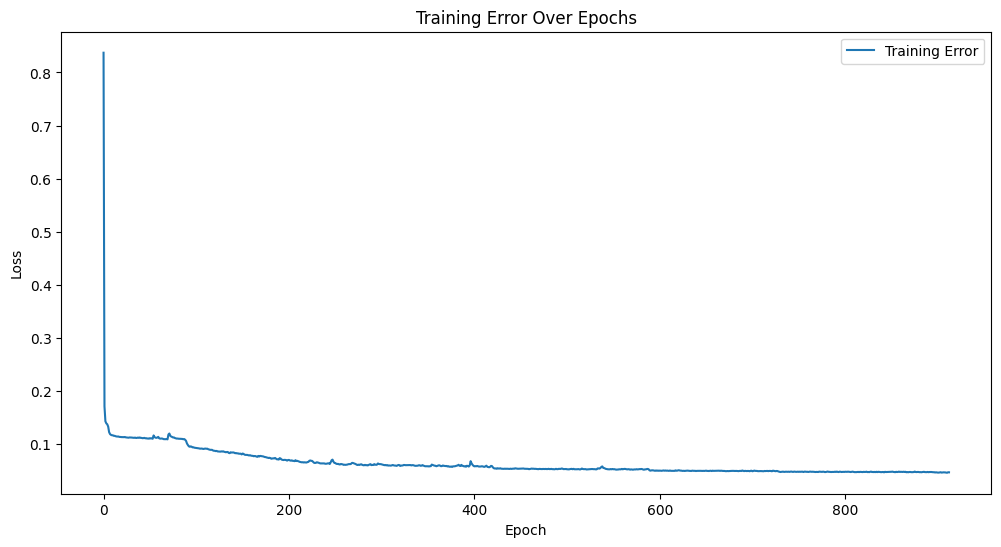

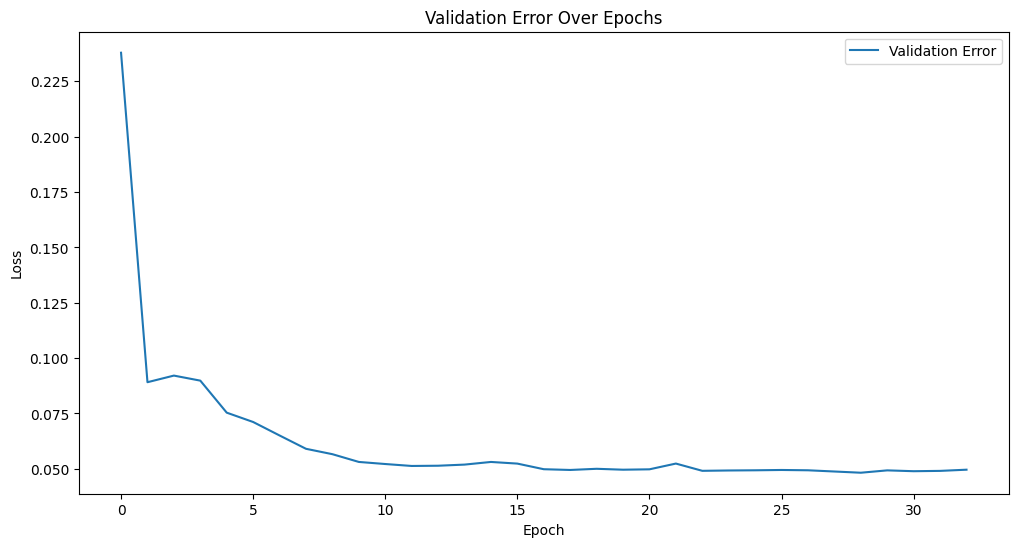

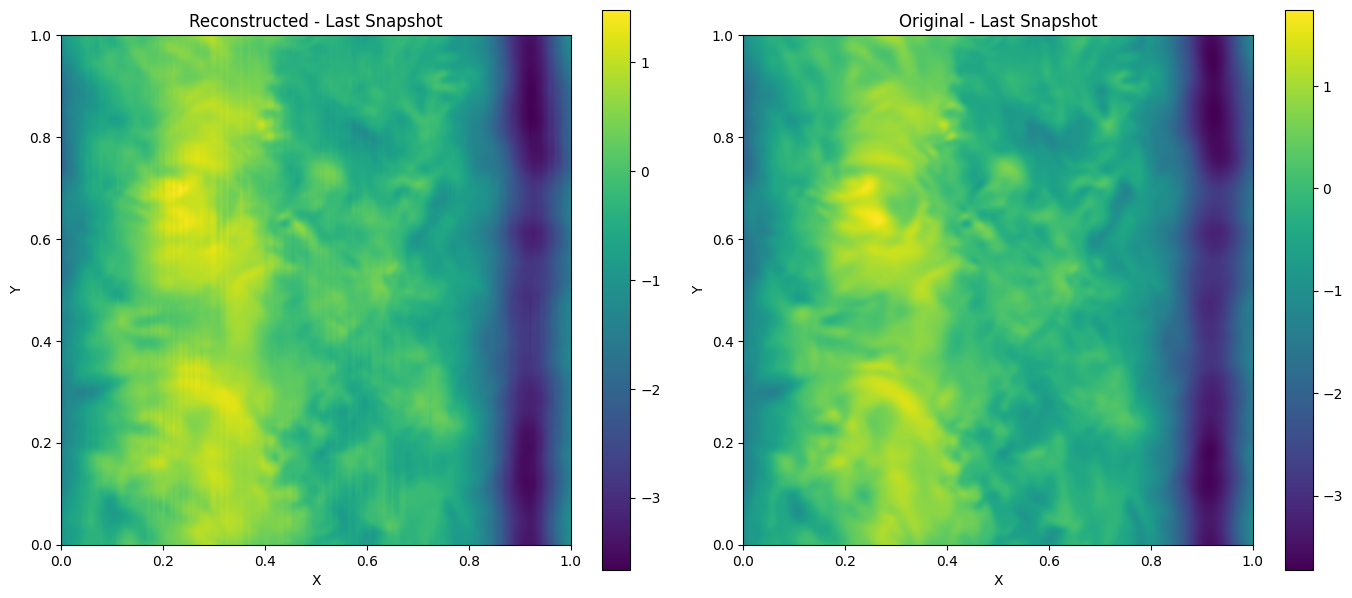

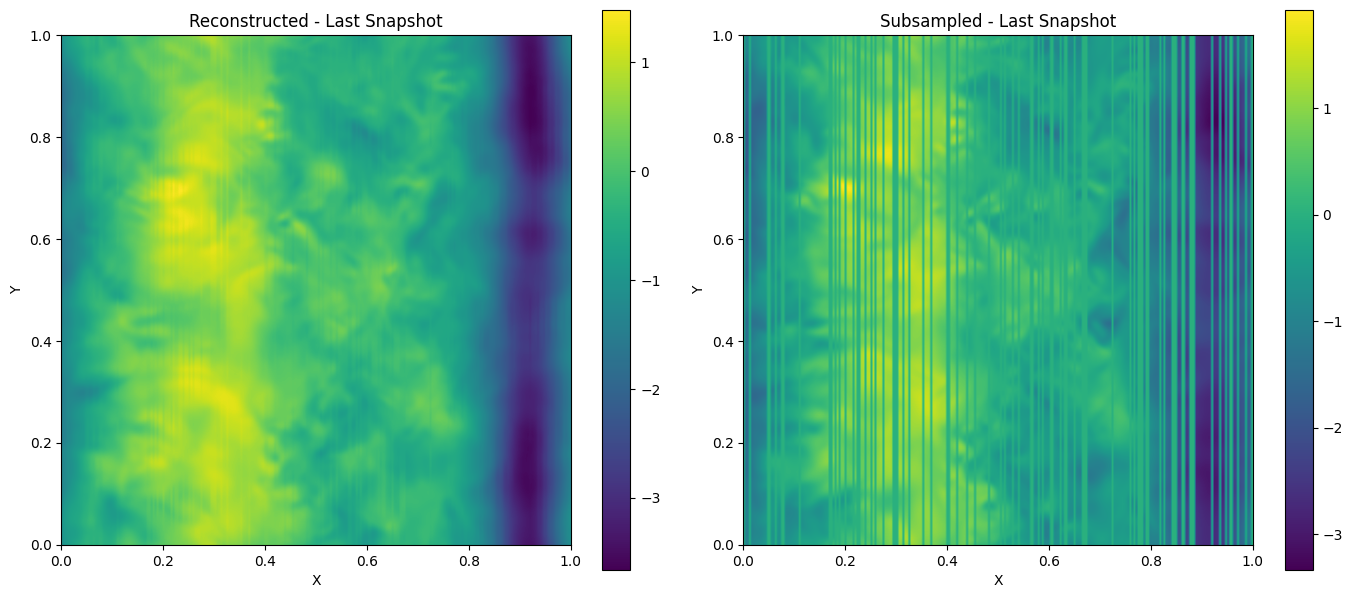

SSIM for the last snapshot: 0.9089786990044653
PSNR for the last snapshot: 25.951343612263123 dB
Normalized Error for the last snapshot: 0.07228104770183563
Mean SSIM for all snapshots: 0.6437284860504081
Mean PSNR for all snapshots: 20.374555277735436 dB
Mean Normalized Error for all snapshots: 0.27247995138168335
Results saved to /home/romulo/Documentos/lpips-env/results/csshred/piv/result_paper/results.json
Plots saved to /home/romulo/Documentos/lpips-env/results/csshred/piv/result_paper


In [48]:
plot_results(
    train_error, validation_errors, test_recons, test_ground_truth, matrix, snapshot,
    save_path=save_path)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/romulo/Documentos/lpips-env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/romulo/Documentos/lpips-env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/romulo/Documentos/lpips-env/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
Shape após reshape: (63, 256, 256)
Shape final dos tensores: torch.Size([1, 1, 256, 256])
LPIPS (perceptual loss): 0.06625239551067352
Resultados atualizados com LPIPS salvos em /home/romulo/Documentos/lpips-env/results/csshred/piv_test/results.json


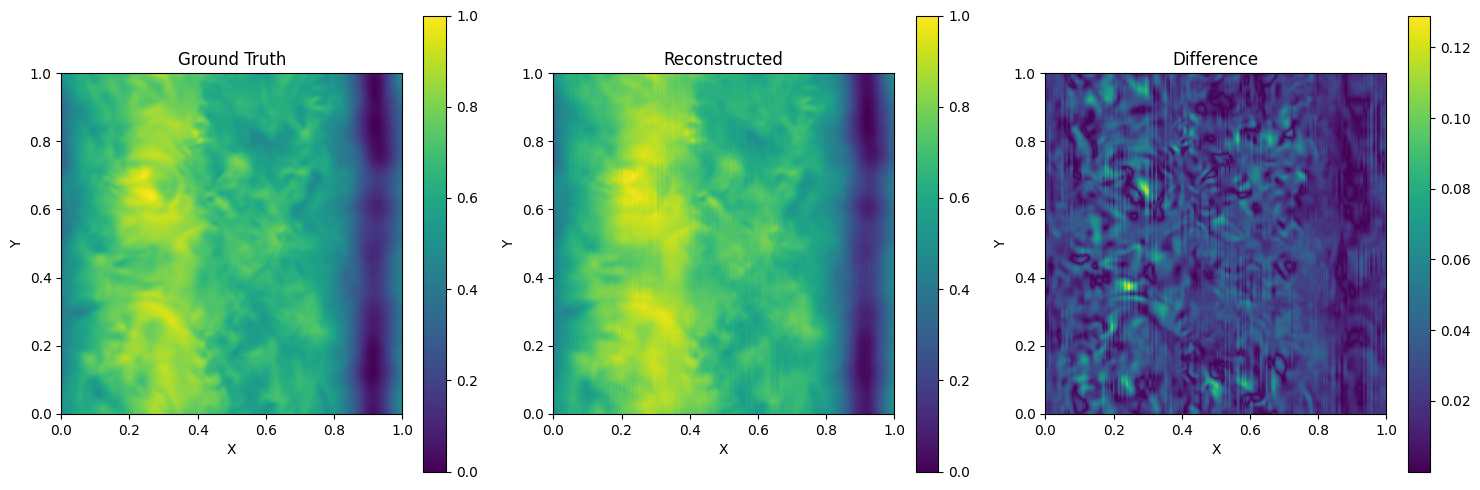

In [32]:
import lpips
import torch
import numpy as np
import matplotlib.pyplot as plt

# Função para reorganizar e preparar os dados
def prepare_for_lpips(gt_flat, rec_flat, original_shape=(256, 256)):
    # Reorganizar os dados do formato achatado para 2D
    gt_reshaped = gt_flat.reshape(-1, *original_shape)  # (timesteps, 256, 256)
    rec_reshaped = rec_flat.reshape(-1, *original_shape)
    
    print(f"Shape após reshape: {gt_reshaped.shape}")
    
    # Pegar o último timestep
    gt_last = gt_reshaped[-1]
    rec_last = rec_reshaped[-1]
    
    # Normalizar para [0,1]
    gt_norm = (gt_last - gt_last.min()) / (gt_last.max() - gt_last.min())
    rec_norm = (rec_last - rec_last.min()) / (rec_last.max() - rec_last.min())
    
    # Converter para tensor e adicionar dimensões de batch e canal
    gt_tensor = torch.from_numpy(gt_norm).unsqueeze(0).unsqueeze(0).float()
    rec_tensor = torch.from_numpy(rec_norm).unsqueeze(0).unsqueeze(0).float()
    
    return gt_tensor, rec_tensor

# Criando o modelo LPIPS
loss_fn = lpips.LPIPS(net='alex', use_dropout=True)

# Preparar as imagens
img0, img1 = prepare_for_lpips(test_ground_truth, test_recons)

print(f"Shape final dos tensores: {img0.shape}")

# Avaliação da similaridade perceptual
d = loss_fn(img0, img1)

lpips_value = d.item()
print(f'LPIPS (perceptual loss): {lpips_value}')

# Carregando o arquivo JSON existente
json_file_path = os.path.join(save_path, "results.json")
with open(json_file_path, "r") as json_file:
    results = json.load(json_file)

# Adicionando a métrica LPIPS aos resultados
results["LPIPS"] = lpips_value

# Salvando o arquivo JSON atualizado
with open(json_file_path, "w") as json_file:
    json.dump(results, json_file, indent=4)

print(f"Resultados atualizados com LPIPS salvos em {json_file_path}")

# Plotar as imagens para verificação
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.imshow(img0.squeeze().numpy(), cmap='viridis', extent=[0, 1, 0, 1])
plt.title('Ground Truth')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar()

plt.subplot(132)
plt.imshow(img1.squeeze().numpy(), cmap='viridis', extent=[0, 1, 0, 1])
plt.title('Reconstructed')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar()

plt.subplot(133)
plt.imshow(np.abs(img0.squeeze().numpy() - img1.squeeze().numpy()), cmap='viridis', extent=[0, 1, 0, 1])
plt.title('Difference')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar()

plt.tight_layout()

# Salvando em PNG e PDF
plt.savefig(os.path.join(save_path, "lpips_comparison.png"))
plt.savefig(os.path.join(save_path, "lpips_comparison.pdf"))
plt.show()

## SHRED

In [36]:
# Define os caminhos de salvamento e carregamento
# save_path = r"./results/csshred/testes"
# load_path = r"./results/csshred/testes"
save_path = r"/home/romulo/Documentos/lpips-env/results/csshred/piv_SHRED/paper"
load_path = r"/home/romulo/Documentos/lpips-env/results/csshred/piv_SHRED/paper"

# Carrega os arquivos necessários
test_recons = np.load(load_path + r"/test_recons.npy")
test_ground_truth = np.load(load_path + r"/test_ground_truth.npy")
matrix = np.load(load_path + r"/matrix.npy")
snapshot = np.load(load_path + r"/snapshot.npy")
sensor_positions_x = np.load(load_path + r"/sensor_positions_x.npy")
sensor_positions_y = np.load(load_path + r"/sensor_positions_y.npy")
# train_error = np.load(load_path + r"/train_error.npy")
validation_errors = np.load(load_path + r"/validation_errors.npy")

In [41]:
import json
import os
import numpy as np
from math import log10
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim

def plot_results(validation_errors, test_recons, test_ground_truth, matrix, subsampled,
    save_path=r'./results/csshred/piv_SHRED/paper'
):
    # Certifique-se de que o diretório de salvamento existe
    os.makedirs(save_path, exist_ok=True)
    
    dim_x, dim_y, dim_t = subsampled.shape

    # Reorganizar os dados mantendo a transposta para visualização
    test_ground_truth = test_ground_truth.copy().reshape(-1, dim_x, dim_y)
    test_ground_truth = np.transpose(test_ground_truth.copy(), (1, 2, 0))
    test_recons = test_recons.reshape(-1, dim_x, dim_y)
    subsampled = subsampled.reshape(dim_x, dim_y, -1)

    print("test_recons shape:", test_recons.shape)
    print("test_ground_truth shape:", test_ground_truth.shape)
    print("subsampled shape:", subsampled.shape)

    # Plot Training Error
    # plt.figure(figsize=(12, 6))
    # plt.plot(train_error, label="Training Error")
    # plt.xlabel("Epoch")
    # plt.ylabel("Loss")
    # plt.title("Training Error Over Epochs")
    # plt.legend()
    # plt.savefig(os.path.join(save_path, "training_error.png"))
    # plt.savefig(os.path.join(save_path, "training_error.pdf"))
    # plt.show()

    # Plot Validation Error
    plt.figure(figsize=(12, 6))
    plt.plot(validation_errors, label="Validation Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Error Over Epochs")
    plt.legend()
    plt.savefig(os.path.join(save_path, "validation_error.png"))
    plt.savefig(os.path.join(save_path, "validation_error.pdf"))
    plt.show()

    # Plot Last Snapshot - Reconstructed and Original
    plt.figure(figsize=(14, 6))

    ax1 = plt.subplot(1, 2, 1)
    img1 = ax1.imshow(test_recons[-1], cmap='viridis', interpolation='bilinear', extent=[0, 1, 0, 1])
    plt.colorbar(img1, ax=ax1)
    ax1.set_title("Reconstructed - Last Snapshot")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    
    ax2 = plt.subplot(1, 2, 2)
    img2 = ax2.imshow(test_ground_truth[:, :, -1], cmap='viridis', interpolation='bilinear', extent=[0, 1, 0, 1])
    plt.colorbar(img2, ax=ax2)
    ax2.set_title("Original - Last Snapshot")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, "last_snapshot_comparison.png"))
    plt.savefig(os.path.join(save_path, "last_snapshot_comparison.pdf"))
    plt.show()

    # Plot Last Snapshot - Reconstructed and Subsampled
    plt.figure(figsize=(14, 6))
    
    ax3 = plt.subplot(1, 2, 1)
    img3 = ax3.imshow(test_recons[-1], cmap='viridis', interpolation='bilinear', extent=[0, 1, 0, 1])
    plt.colorbar(img3, ax=ax3)
    ax3.set_title("Reconstructed - Last Snapshot")
    ax3.set_xlabel("X")
    ax3.set_ylabel("Y")
    
    ax4 = plt.subplot(1, 2, 2)
    img4 = ax4.imshow(subsampled[:, :, -1], cmap='viridis', interpolation='bilinear', extent=[0, 1, 0, 1])
    plt.colorbar(img4, ax=ax4)
    ax4.set_title("Subsampled - Last Snapshot")
    ax4.set_xlabel("X")
    ax4.set_ylabel("Y")
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, "subsampled_snapshot_comparison.png"))
    plt.savefig(os.path.join(save_path, "subsampled_snapshot_comparison.pdf"))
    plt.show()
    
    # Calculando métricas
    ssim_value_last = ssim(
        test_ground_truth[:, :, -1],
        test_recons[-1],
        data_range=test_ground_truth[:, :, -1].max() - test_ground_truth[:, :, -1].min(),
    )
    
    test_recons_mse = np.transpose(test_recons.copy(), (1,2,0))
    mse_value_last = np.linalg.norm(test_recons_mse - test_ground_truth) / np.linalg.norm(test_ground_truth)
    
    mse = mean_squared_error(test_ground_truth[:, :, -1], test_recons[-1])
    max_pixel = np.max(test_ground_truth[:, :, -1])
    psnr_value_last = 20 * log10(max_pixel / np.sqrt(mse))
    
    # Cálculo do erro normalizado
    error_norm_last = np.linalg.norm(test_recons[-1] - test_ground_truth[:, :, -1]) / np.linalg.norm(test_ground_truth[:, :, -1])
    
    print(f"SSIM for the last snapshot: {ssim_value_last}")
    print(f"MSE for the last snapshot: {mse_value_last}")
    print(f"PSNR for the last snapshot: {psnr_value_last} dB")
    print(f"Normalized Error for the last snapshot: {error_norm_last}")

    # Calculando médias para todos os snapshots
    ssim_values = []
    psnr_values = []
    error_norms = []  # Lista para armazenar os erros normalizados
    for i in range(test_recons.shape[0]):
        ssim_value = ssim(
            test_ground_truth[:, :, i],
            test_recons[i],
            data_range=test_ground_truth[:, :, i].max() - test_ground_truth[:, :, i].min(),
        )
        ssim_values.append(ssim_value)
        
        mse = mean_squared_error(test_ground_truth[:, :, i], test_recons[i])
        max_pixel = np.max(test_ground_truth[:, :, i])
        psnr = 20 * log10(max_pixel / np.sqrt(mse))
        psnr_values.append(psnr)

        # Cálculo do erro normalizado para cada snapshot
        error_norm = np.linalg.norm(test_recons[i] - test_ground_truth[:, :, i]) / np.linalg.norm(test_ground_truth[:, :, i])
        error_norms.append(error_norm)

    mean_ssim_value = np.mean(ssim_values)
    mean_psnr_value = np.mean(psnr_values)
    mean_error_norm = np.mean(error_norms)  # Média dos erros normalizados
    print(f"Mean SSIM for all snapshots: {mean_ssim_value}")
    print(f"Mean PSNR for all snapshots: {mean_psnr_value} dB")
    print(f"Mean Normalized Error for all snapshots: {mean_error_norm}")

    # Salvando resultados em JSON
    results = {
        "SSIM_last_snapshot": float(ssim_value_last),
        # "MSE_last_snapshot": float(mse_value_last),
        "PSNR_last_snapshot": float(psnr_value_last),
        "Normalized_Error_last_snapshot": float(error_norm_last),  # Adicionando erro normalizado
        "Mean_SSIM_all_snapshots": float(mean_ssim_value),
        "Mean_PSNR_all_snapshots": float(mean_psnr_value),
        "Mean_Normalized_Error_all_snapshots": float(mean_error_norm),  # Adicionando média do erro normalizado
    }
    
    json_file_path = os.path.join(save_path, "results.json")
    with open(json_file_path, "w") as json_file:
        json.dump(results, json_file, indent=4)
    
    print(f"Results saved to {json_file_path}")
    print(f"Plots saved to {save_path}")

test_recons shape: (63, 256, 256)
test_ground_truth shape: (256, 256, 63)
subsampled shape: (256, 256, 650)


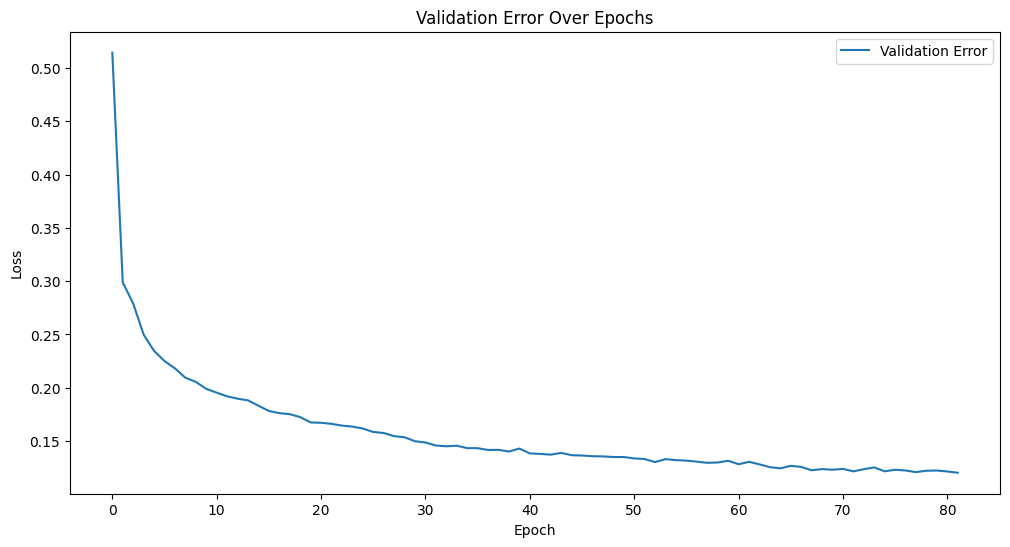

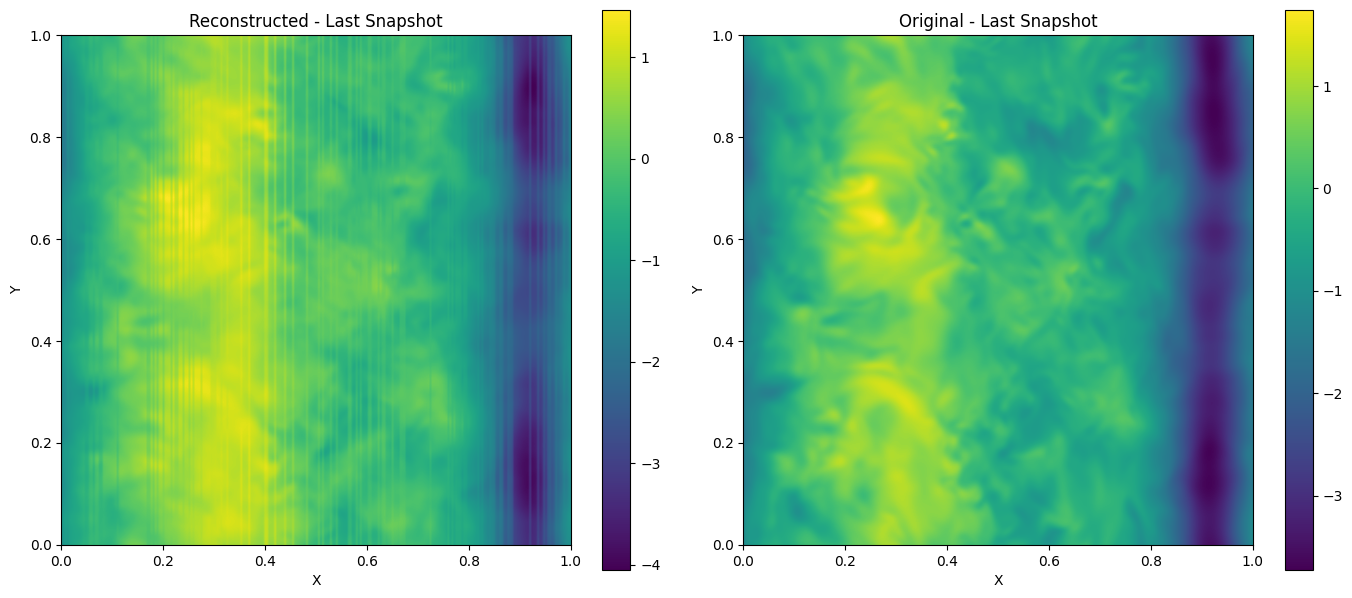

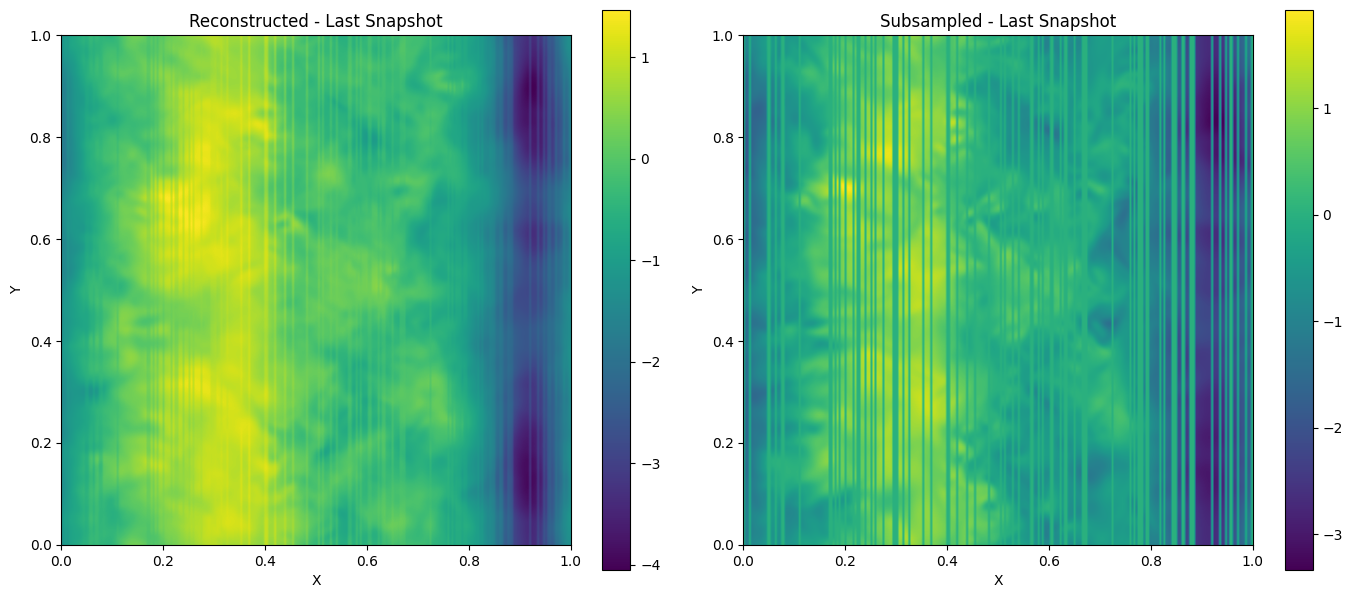

SSIM for the last snapshot: 0.6918170276213768
MSE for the last snapshot: 0.25290271639823914
PSNR for the last snapshot: 19.276981699657092 dB
Normalized Error for the last snapshot: 0.15586282312870026
Mean SSIM for all snapshots: 0.6223040485907848
Mean PSNR for all snapshots: 20.155695190929972 dB
Mean Normalized Error for all snapshots: 0.24671456217765808
Results saved to ./results/csshred/piv_SHRED/paper/results.json
Plots saved to ./results/csshred/piv_SHRED/paper


In [42]:
plot_results(validation_errors, test_recons, test_ground_truth, matrix, snapshot, save_path=save_path)

In [ ]:
import lpips
import torch
import numpy as np
import matplotlib.pyplot as plt

# Função para reorganizar e preparar os dados
def prepare_for_lpips(gt_flat, rec_flat, original_shape=(256, 256)):
    # Reorganizar os dados do formato achatado para 2D
    gt_reshaped = gt_flat.reshape(-1, *original_shape)  # (timesteps, 256, 256)
    rec_reshaped = rec_flat.reshape(-1, *original_shape)
    
    print(f"Shape após reshape: {gt_reshaped.shape}")
    
    # Pegar o último timestep
    gt_last = gt_reshaped[-1]
    rec_last = rec_reshaped[-1]
    
    # Normalizar para [0,1]
    gt_norm = (gt_last - gt_last.min()) / (gt_last.max() - gt_last.min())
    rec_norm = (rec_last - rec_last.min()) / (rec_last.max() - rec_last.min())
    
    # Converter para tensor e adicionar dimensões de batch e canal
    gt_tensor = torch.from_numpy(gt_norm).unsqueeze(0).unsqueeze(0).float()
    rec_tensor = torch.from_numpy(rec_norm).unsqueeze(0).unsqueeze(0).float()
    
    return gt_tensor, rec_tensor

# Criando o modelo LPIPS
loss_fn = lpips.LPIPS(net='alex', use_dropout=True)

# Preparar as imagens
img0, img1 = prepare_for_lpips(test_ground_truth, test_recons)

print(f"Shape final dos tensores: {img0.shape}")

# Avaliação da similaridade perceptual
d = loss_fn(img0, img1)

lpips_value = d.item()
print(f'LPIPS (perceptual loss): {lpips_value}')

# Carregando o arquivo JSON existente
json_file_path = os.path.join(save_path, "results.json")
with open(json_file_path, "r") as json_file:
    results = json.load(json_file)

# Adicionando a métrica LPIPS aos resultados
results["LPIPS"] = lpips_value

# Salvando o arquivo JSON atualizado
with open(json_file_path, "w") as json_file:
    json.dump(results, json_file, indent=4)

print(f"Resultados atualizados com LPIPS salvos em {json_file_path}")

# Plotar as imagens para verificação
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.imshow(img0.squeeze().numpy(), cmap='viridis')
plt.title('Ground Truth')
plt.colorbar()

plt.subplot(132)
plt.imshow(img1.squeeze().numpy(), cmap='viridis')
plt.title('Reconstructed')
plt.colorbar()

plt.subplot(133)
plt.imshow(np.abs(img0.squeeze().numpy() - img1.squeeze().numpy()), cmap='viridis')
plt.title('Difference')
plt.colorbar()

plt.tight_layout()

plt.savefig(os.path.join(save_path, "lpips_comparison.png"))
plt.show()